# CIC-IDS2017 : CNN-BiLSTM Multiclass Intrusion Detection
**Pipeline:** Preprocessing -> PyTorch DataLoaders -> CNN-BiLSTM -> 5-Fold CV -> Evaluation

**Task:** Multiclass classification : BENIGN + 14 attack sub-categories

**Dataset:** CIC-IDS2017 : 78 numerical features, ~2M samples, extreme imbalance (up to ×144,653 for Heartbleed)

## 1. Configuration

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
DATA_PATH        = '/content/drive/MyDrive/Tez_kodu/CIC_IDS_2017/'
MISSING_STRATEGY = 'mean'
SCALING          = 'quantile'
SPLIT            = 'stratified'
OVERSAMPLING     = 'smote'
TASK             = 'multiclass'
LOSS_CHOICE      = 'focal'
TEST_SIZE        = 0.2
RANDOM_STATE     = 42

# CNN Hyperparameters
BATCH_SIZE   = 512
EPOCHS       = 100
LR           = 1e-3
N_FOLDS      = 5
PATIENCE     = 5

# CNN blocks: list of (out_channels, kernel_size)
# Each block: Conv1d → BN → ReLU → Dropout → MaxPool1d(2)
CNN_BLOCKS   = [(64, 3), (128, 3), (256, 3)]
CNN_DROPOUT  = 0.3
POOL_SIZE    = 2

# Classifier head
FC_LAYERS    = [256, 128]
FC_DROPOUT   = 0.4

print(' Configuration loaded')
print(f'  Dataset: CIC-IDS2017 | Task: {TASK}')
print(f'  Scaling: {SCALING} | Oversampling: {OVERSAMPLING} | Loss: {LOSS_CHOICE}')
print(f'  CNN blocks: {CNN_BLOCKS}')
print(f'  Batch: {BATCH_SIZE} | Epochs: {EPOCHS} | Folds: {N_FOLDS} | Patience: {PATIENCE}')

 Configuration loaded
  Dataset: CIC-IDS2017 | Task: multiclass
  Scaling: quantile | Oversampling: smote | Loss: focal
  CNN blocks: [(64, 3), (128, 3), (256, 3)]
  Batch: 512 | Epochs: 100 | Folds: 5 | Patience: 5


## 2. Imports

In [4]:
import os, glob, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, QuantileTransformer,
    LabelEncoder, label_binarize
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, accuracy_score,
    precision_score, recall_score,
    precision_recall_curve, roc_curve, auc
)

from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN, RandomOverSampler
from imblearn.combine import SMOTETomek

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f' Imports OK  |  Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')

 Imports OK  |  Device: cuda
  GPU: NVIDIA L4


## 3. Data Loading

In [5]:
if os.path.isdir(DATA_PATH):
    csv_files = glob.glob(os.path.join(DATA_PATH, '*.csv'))
    print(f'{len(csv_files)} CSV files found:')
    for f in sorted(csv_files):
        print(f'   {os.path.basename(f)}')
    df = pd.concat(
        [pd.read_csv(f, low_memory=False) for f in sorted(csv_files)],
        ignore_index=True
    )
else:
    df = pd.read_csv(DATA_PATH, low_memory=False)

# Standardize column names — CIC-IDS2017 has spaces in column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

print(f'\nShape: {df.shape}')
print(f'Columns sample: {list(df.columns[:8])}')
print(f'Label column  : {[c for c in df.columns if "label" in c]}')

8 CSV files found:
   Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
   Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
   Friday-WorkingHours-Morning.pcap_ISCX.csv
   Monday-WorkingHours.pcap_ISCX.csv
   Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
   Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
   Tuesday-WorkingHours.pcap_ISCX.csv
   Wednesday-workingHours.pcap_ISCX.csv

Shape: (2830743, 79)
Columns sample: ['destination_port', 'flow_duration', 'total_fwd_packets', 'total_backward_packets', 'total_length_of_fwd_packets', 'total_length_of_bwd_packets', 'fwd_packet_length_max', 'fwd_packet_length_min']
Label column  : ['label']


## 4. Cleaning & Encoding

In [6]:
# 4.1 Infinite -> NaN
inf_count = np.isinf(df.select_dtypes(include=np.number)).sum().sum()
df.replace([np.inf, -np.inf], np.nan, inplace=True)
print(f'{inf_count:,} infinite values replaced by NaN')

# 4.2 Missing values
nan_total = df.isnull().sum().sum()
print(f'NaN before: {nan_total:,}')
if MISSING_STRATEGY == 'drop':
    df.dropna(inplace=True)
else:
    num_cols = df.select_dtypes(include=np.number).columns
    df[num_cols] = df[num_cols].fillna(df[num_cols].mean())
print(f'NaN after : {df.isnull().sum().sum()}')

# 4.3 Multiclass target
label_col = 'label'

# Strip whitespace and normalize
df[label_col] = df[label_col].astype(str).str.strip()

print('\nOriginal Label distribution (all classes):')
vc = df[label_col].value_counts().sort_values(ascending=False)
for name, count in vc.items():
    print(f'  {name:<40} {count:>10,}  ({count/len(df)*100:.2f}%)')

# Encode with LabelEncoder : preserves all 15 class names
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df[label_col])
CLASS_NAMES = list(le.classes_)
N_CLASSES   = len(CLASS_NAMES)

print(f'\nLabel encoding ({N_CLASSES} classes):')
for i, cls in enumerate(CLASS_NAMES):
    cnt = (df['label_encoded'] == i).sum()
    print(f'  {i:2d} : {cls:<40} {cnt:>10,}')

# 4.4 Feature matrix — CIC-IDS2017 is all-numerical, no categorical encoding
EXCLUDE      = [label_col, 'label_encoded']
FEATURE_COLS = [c for c in df.select_dtypes(include=np.number).columns
                if c not in EXCLUDE]
X = df[FEATURE_COLS].copy().astype(np.float32)
y = df['label_encoded'].values.astype(np.int64)

N_FEATURES = X.shape[1]
print(f'\nFeatures: {N_FEATURES} | Samples: {X.shape[0]:,} | Classes: {N_CLASSES}')

4,376 infinite values replaced by NaN
NaN before: 5,734
NaN after : 0

Original Label distribution (all classes):
  BENIGN                                    2,273,097  (80.30%)
  DoS Hulk                                    231,073  (8.16%)
  PortScan                                    158,930  (5.61%)
  DDoS                                        128,027  (4.52%)
  DoS GoldenEye                                10,293  (0.36%)
  FTP-Patator                                   7,938  (0.28%)
  SSH-Patator                                   5,897  (0.21%)
  DoS slowloris                                 5,796  (0.20%)
  DoS Slowhttptest                              5,499  (0.19%)
  Bot                                           1,966  (0.07%)
  Web Attack � Brute Force                      1,507  (0.05%)
  Web Attack � XSS                                652  (0.02%)
  Infiltration                                     36  (0.00%)
  Web Attack � Sql Injection                       21  (0.00%)
  H

## 5. Train / Validation / Test Split

In [7]:
# Stratified split is critical — Heartbleed has only ~11 samples
stratify_param = y if SPLIT == 'stratified' else None
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=stratify_param
)
stratify_temp = y_temp if SPLIT == 'stratified' else None
X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp, test_size=0.333, random_state=RANDOM_STATE, stratify=stratify_temp
)
print(f'Split ({SPLIT})')
print(f'  Train      : {X_train.shape[0]:,}  (70%)')
print(f'  Validation : {X_val.shape[0]:,}   (10%)')
print(f'  Test       : {X_test.shape[0]:,}   (20%)')

# Show smallest class counts per split to verify stratification
print('\nSmallest class counts per split (stratification check):')
for split_name, y_split in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    y_arr  = y_split if isinstance(y_split, np.ndarray) else np.array(y_split)
    counts = np.bincount(y_arr, minlength=N_CLASSES)
    min_c  = counts.min()
    min_cl = CLASS_NAMES[counts.argmin()]
    print(f'  {split_name}: min class = "{min_cl}" with {min_c} samples')

Split (stratified)
  Train      : 1,981,520  (70%)
  Validation : 282,792   (10%)
  Test       : 566,431   (20%)

Smallest class counts per split (stratification check):
  Train: min class = "Heartbleed" with 8 samples
  Val: min class = "Heartbleed" with 1 samples
  Test: min class = "Heartbleed" with 2 samples


## 6. Scaling

In [8]:
# CIC-IDS2017 has severe scale disparities across 78 features
if SCALING is None:
    X_train_scaled = X_train.values.astype(np.float32)
    X_val_scaled   = X_val.values.astype(np.float32)
    X_test_scaled  = X_test.values.astype(np.float32)
    print('No scaling applied')
else:
    scalers = {
        'standard': StandardScaler(),
        'minmax'  : MinMaxScaler(),
        'quantile': QuantileTransformer(output_distribution='normal',
                                        random_state=RANDOM_STATE)
    }
    scaler = scalers[SCALING]
    X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
    X_val_scaled   = scaler.transform(X_val).astype(np.float32)
    X_test_scaled  = scaler.transform(X_test).astype(np.float32)
    print(f' Scaling [{SCALING}] applied — fit on train only')
    print(f'  Train mean (post-scale): {X_train_scaled.mean():.4f}  std: {X_train_scaled.std():.4f}')

 Scaling [quantile] applied — fit on train only
  Train mean (post-scale): -2.2084  std: 2.9395


## 7. Oversampling (train only)

In [9]:
# CIC-IDS2017 multiclass: extreme imbalance
# BENIGN ~1.59M vs Heartbleed ~11 (ratio ×144,653)
# NOTE: SMOTE requires ≥ k_neighbors+1 samples per class.
# Classes with < 6 samples (Heartbleed, SQL Injection) may need
# RandomOverSampler as fallback or SMOTE with k_neighbors=1.
y_train_arr = y_train if isinstance(y_train, np.ndarray) else np.array(y_train)
counts_before = np.bincount(y_train_arr, minlength=N_CLASSES)
print('Distribution before oversampling:')
for i, (cls, cnt) in enumerate(zip(CLASS_NAMES, counts_before)):
    print(f'  {i:2d} {cls:<40} {cnt:>10,}')

if OVERSAMPLING is None:
    X_train_res, y_train_res = X_train_scaled, y_train_arr
    print('No oversampling')
else:
    # Use k_neighbors=1 for SMOTE to handle very small classes (Heartbleed etc.)
    oversamplers = {
        'smote'           : SMOTE(random_state=RANDOM_STATE, k_neighbors=1),
        'borderline_smote': BorderlineSMOTE(random_state=RANDOM_STATE, k_neighbors=1),
        'adasyn'          : ADASYN(random_state=RANDOM_STATE),
        'smote_tomek'     : SMOTETomek(random_state=RANDOM_STATE),
        'random'          : RandomOverSampler(random_state=RANDOM_STATE)
    }
    print(f'Applying {OVERSAMPLING}... (may take several minutes on ~1.1M train samples)')
    sampler = oversamplers[OVERSAMPLING]
    X_train_res, y_train_res = sampler.fit_resample(X_train_scaled, y_train_arr)
    X_train_res = X_train_res.astype(np.float32)
    y_train_res = y_train_res.astype(np.int64)
    print(f' {OVERSAMPLING} applied')

counts_after = np.bincount(y_train_res, minlength=N_CLASSES)
print('\nDistribution after oversampling:')
for i, (cls, cnt_b, cnt_a) in enumerate(zip(CLASS_NAMES, counts_before, counts_after)):
    ratio = cnt_a / (cnt_b + 1e-8)
    print(f'  {i:2d} {cls:<40} {cnt_a:>10,}  (×{ratio:.1f})')
print(f'\nTotal train size after: {X_train_res.shape[0]:,}')

Distribution before oversampling:
   0 BENIGN                                    1,591,168
   1 Bot                                           1,376
   2 DDoS                                         89,619
   3 DoS GoldenEye                                 7,205
   4 DoS Hulk                                    161,751
   5 DoS Slowhttptest                              3,849
   6 DoS slowloris                                 4,057
   7 FTP-Patator                                   5,557
   8 Heartbleed                                        8
   9 Infiltration                                     25
  10 PortScan                                    111,251
  11 SSH-Patator                                   4,128
  12 Web Attack � Brute Force                      1,055
  13 Web Attack � Sql Injection                       15
  14 Web Attack � XSS                                456
Applying smote... (may take several minutes on ~1.1M train samples)
 smote applied

Distribution after oversamp

## 8. PyTorch Dataset & DataLoaders

In [10]:
class IDSDataset(Dataset):
    """Input shape: (N, 1, F) — 1 channel, F=78 features as 1-D sequence."""
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)  # (N,1,F)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):           return len(self.y)
    def __getitem__(self, idx):  return self.X[idx], self.y[idx]


def make_loader(X, y, batch_size, shuffle=True):
    return DataLoader(
        IDSDataset(X, y),
        batch_size  = batch_size,
        shuffle     = shuffle,
        drop_last   = True,
        num_workers = 0,
        pin_memory  = (DEVICE.type == 'cuda')
    )


train_loader = make_loader(X_train_res,   y_train_res, BATCH_SIZE, shuffle=True)
val_loader   = make_loader(X_val_scaled,  y_val,       BATCH_SIZE, shuffle=False)
test_loader  = make_loader(X_test_scaled, y_test,      BATCH_SIZE, shuffle=False)

print(f' DataLoaders created (drop_last=True)')
print(f'  Train batches: {len(train_loader):,}')
print(f'  Val   batches: {len(val_loader):,}')
print(f'  Test  batches: {len(test_loader):,}')
xb, yb = next(iter(train_loader))
print(f'  Batch shape  : X={tuple(xb.shape)}  y={tuple(yb.shape)}')

 DataLoaders created (drop_last=True)
  Train batches: 46,616
  Val   batches: 552
  Test  batches: 1,106
  Batch shape  : X=(512, 1, 78)  y=(512,)


## 9. CNN Architecture

In [11]:
class CNN1D(nn.Module):
    def __init__(self, n_features, n_classes,
                 blocks=None, cnn_dropout=0.3,
                 pool_size=2, fc_layers=None, fc_dropout=0.4):
        super().__init__()
        if blocks    is None: blocks    = [(64,3),(128,3),(256,3)]
        if fc_layers is None: fc_layers = [256, 128]

        #  Convolutional blocks
        cnn_mods = []
        in_ch = 1
        for out_ch, k in blocks:
            cnn_mods += [
                nn.Conv1d(in_ch, out_ch, kernel_size=k,
                          padding=k // 2, bias=False),
                nn.BatchNorm1d(out_ch),
                nn.ReLU(inplace=True),
                nn.Dropout(cnn_dropout),
            ]
            if pool_size > 1:
                cnn_mods.append(nn.MaxPool1d(pool_size))
            in_ch = out_ch
        self.cnn    = nn.Sequential(*cnn_mods)
        self.gap    = nn.AdaptiveAvgPool1d(1)
        cnn_out_dim = blocks[-1][0]

        #  Fully-connected head
        fc_mods = []
        in_dim  = cnn_out_dim
        for out_dim in fc_layers:
            fc_mods += [
                nn.Linear(in_dim, out_dim, bias=False),
                nn.BatchNorm1d(out_dim),
                nn.ReLU(inplace=True),
                nn.Dropout(fc_dropout),
            ]
            in_dim = out_dim
        fc_mods.append(nn.Linear(in_dim, n_classes))
        self.head = nn.Sequential(*fc_mods)

    def forward(self, x):
        x = self.cnn(x)       # (B, 256, F//8)
        x = self.gap(x)       # (B, 256, 1)
        x = x.squeeze(-1)     # (B, 256)
        return self.head(x)   # (B, N_CLASSES)


def build_model():
    return CNN1D(
        n_features  = N_FEATURES,
        n_classes   = N_CLASSES,
        blocks      = CNN_BLOCKS,
        cnn_dropout = CNN_DROPOUT,
        pool_size   = POOL_SIZE,
        fc_layers   = FC_LAYERS,
        fc_dropout  = FC_DROPOUT
    ).to(DEVICE)


model = build_model()
total_p   = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTotal params    : {total_p:,}')
print(f'Trainable params: {trainable:,}')
with torch.no_grad():
    dummy = torch.zeros(4, 1, N_FEATURES).to(DEVICE)
    out   = model(dummy)
    print(f'Output shape    : {tuple(out.shape)}  <- (batch=4, classes={N_CLASSES})')
del model

CNN1D(
  (cnn): Sequential(
    (0): Conv1d(1, 64, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU(inplace=True)
    (8): Dropout(p=0.3, inplace=False)
    (9): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
    (11): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): Dropout(p=0.3, inplace=False)
    (14): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)


## 10. Loss Function (Multiclass Focal Loss)

In [12]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None, reduction='mean'):
        super().__init__()
        self.gamma = gamma; self.alpha = alpha; self.reduction = reduction

    def forward(self, inputs, targets):
        log_probs = F.log_softmax(inputs, dim=1)
        probs     = torch.exp(log_probs)
        log_pt    = log_probs.gather(1, targets.view(-1,1)).squeeze(1)
        pt        = probs.gather(1,     targets.view(-1,1)).squeeze(1)
        focal     = -((1 - pt) ** self.gamma) * log_pt
        if self.alpha is not None:
            alpha_t = self.alpha.to(inputs.device)[targets]
            focal   = alpha_t * focal
        return focal.mean() if self.reduction == 'mean' else focal.sum()


def get_loss_fn(choice, y_labels):
    if choice == 'focal':
        return FocalLoss(gamma=2.0)
    elif choice == 'weighted_ce':
        counts  = np.bincount(y_labels, minlength=N_CLASSES).astype(np.float32)
        weights = 1.0 / (counts + 1e-6)
        weights = weights / weights.sum() * N_CLASSES
        return nn.CrossEntropyLoss(
            weight=torch.tensor(weights, dtype=torch.float32).to(DEVICE)
        )
    else:
        return nn.CrossEntropyLoss()


print(f' Loss function: {LOSS_CHOICE}')

 Loss function: focal


## 11. Training & Evaluation Functions

In [13]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
        optimizer.zero_grad()
        logits = model(X_b)
        loss   = criterion(logits, y_b)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * X_b.size(0)
        correct    += (logits.argmax(1) == y_b).sum().item()
        total      += X_b.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    """Returns loss, accuracy, argmax predictions, targets, full softmax probs."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_probs, all_preds, all_targets = [], [], []
    t0 = time.perf_counter()

    for X_b, y_b in loader:
        X_b, y_b   = X_b.to(DEVICE), y_b.to(DEVICE)
        logits     = model(X_b)
        loss       = criterion(logits, y_b)
        probs      = F.softmax(logits, dim=1)   # (B, N_CLASSES)
        preds      = logits.argmax(dim=1)
        total_loss += loss.item() * X_b.size(0)
        correct    += (preds == y_b).sum().item()
        total      += X_b.size(0)
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_targets.append(y_b.cpu().numpy())

    elapsed = time.perf_counter() - t0
    return {
        'loss'     : total_loss / total,
        'acc'      : correct / total,
        'probs'    : np.concatenate(all_probs),
        'preds'    : np.concatenate(all_preds),
        'targets'  : np.concatenate(all_targets),
        'time_s'   : elapsed,
        'n_samples': total
    }


def train_model(model, train_loader, val_loader,
                criterion, optimizer, epochs, patience,
                verbose=True, fold_id=None):
    history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
    best_val_loss = float('inf')
    best_state    = None
    no_improve    = 0
    prefix        = f'[Fold {fold_id}] ' if fold_id else ''

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc   = train_one_epoch(model, train_loader, optimizer, criterion)
        val_res           = evaluate(model, val_loader, criterion)
        val_loss, val_acc = val_res['loss'], val_res['acc']

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve    = 0
        else:
            no_improve += 1

        if verbose and (epoch % 5 == 0 or epoch == 1):
            print(f'{prefix}Epoch {epoch:3d}/{epochs} '
                  f'| tr_loss={tr_loss:.4f} tr_acc={tr_acc:.4f} '
                  f'| val_loss={val_loss:.4f} val_acc={val_acc:.4f} '
                  f'| patience={no_improve}/{patience}')

        if no_improve >= patience:
            if verbose:
                print(f'{prefix}Early stopping at epoch {epoch} '
                      f'(best val_loss={best_val_loss:.4f})')
            break

    model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
    return history, best_val_loss


print(' Training functions defined')

 Training functions defined


## 12. 5-Fold Cross-Validation

In [14]:
X_cv = np.vstack([X_train_scaled, X_val_scaled]).astype(np.float32)
y_cv = np.concatenate([
    y_train if isinstance(y_train, np.ndarray) else np.array(y_train),
    y_val   if isinstance(y_val,   np.ndarray) else np.array(y_val)
]).astype(np.int64)

skf              = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_histories     = []
cv_results       = []
fold_best_states = []

print(f' Starting {N_FOLDS}-Fold CV - CNN Multiclass (CIC-IDS2017)')
print(f'  CV pool: {X_cv.shape[0]:,} | Features: {N_FEATURES} | Classes: {N_CLASSES}')


for fold, (tr_idx, vl_idx) in enumerate(skf.split(X_cv, y_cv), start=1):
    print(f'\n FOLD {fold}/{N_FOLDS}')

    X_tr, y_tr = X_cv[tr_idx], y_cv[tr_idx]
    X_vl, y_vl = X_cv[vl_idx], y_cv[vl_idx]

    # Per-fold oversampling on train split only
    if OVERSAMPLING is not None:
        sampler    = SMOTE(random_state=RANDOM_STATE, k_neighbors=1)
        X_tr, y_tr = sampler.fit_resample(X_tr, y_tr)
        X_tr       = X_tr.astype(np.float32)
        y_tr       = y_tr.astype(np.int64)

    fold_train = make_loader(X_tr, y_tr, BATCH_SIZE, shuffle=True)
    fold_val   = make_loader(X_vl, y_vl, BATCH_SIZE, shuffle=False)

    model     = build_model()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = get_loss_fn(LOSS_CHOICE, y_tr)

    history, _ = train_model(
        model, fold_train, fold_val,
        criterion, optimizer,
        epochs=EPOCHS, patience=PATIENCE,
        verbose=True, fold_id=fold
    )

    res = evaluate(model, fold_val, criterion)
    preds, targets, probs = res['preds'], res['targets'], res['probs']

    acc  = accuracy_score(targets, preds)
    prec = precision_score(targets, preds, average='macro', zero_division=0)
    rec  = recall_score(targets, preds,    average='macro', zero_division=0)
    f1   = f1_score(targets, preds,        average='macro', zero_division=0)

    # FPR macro: per-class FP/(FP+TN)
    cm_f = confusion_matrix(targets, preds, labels=list(range(N_CLASSES)))
    fprs = []
    for c in range(N_CLASSES):
        fp = cm_f[:, c].sum() - cm_f[c, c]
        tn = cm_f.sum() - cm_f[c,:].sum() - cm_f[:,c].sum() + cm_f[c,c]
        fprs.append(fp / (fp + tn + 1e-8))
    fpr_macro = np.mean(fprs)

    try:
        roc_auc = roc_auc_score(targets, probs, multi_class='ovr', average='macro')
    except ValueError:
        roc_auc = float('nan')

    det_time_ms = (res['time_s'] / res['n_samples']) * 1000
    throughput  = res['n_samples'] / res['time_s']

    cv_results.append({
        'fold': fold, 'acc': acc, 'precision': prec, 'recall': rec,
        'f1': f1, 'fpr': fpr_macro, 'roc_auc': roc_auc,
        'det_time_ms': det_time_ms, 'throughput': throughput
    })
    cv_histories.append(history)
    fold_best_states.append({k: v.clone() for k, v in model.state_dict().items()})

    print(f'  Fold {fold} → Acc={acc:.4f} F1={f1:.4f} '
          f'Prec={prec:.4f} Rec={rec:.4f} '
          f'FPR={fpr_macro:.4f} AUC={roc_auc:.4f}')

print(' Cross-Validation complete')

 Starting 5-Fold CV - CNN Multiclass (CIC-IDS2017)
  CV pool: 2,264,312 | Features: 78 | Classes: 15

 FOLD 1/5
[Fold 1] Epoch   1/100 | tr_loss=0.0389 tr_acc=0.9317 | val_loss=0.0268 val_acc=0.9729 | patience=0/5
[Fold 1] Epoch   5/100 | tr_loss=0.0251 tr_acc=0.9467 | val_loss=0.0119 val_acc=0.9838 | patience=0/5
[Fold 1] Epoch  10/100 | tr_loss=0.0242 tr_acc=0.9485 | val_loss=0.0122 val_acc=0.9844 | patience=5/5
[Fold 1] Early stopping at epoch 10 (best val_loss=0.0119)
  Fold 1 → Acc=0.9838 F1=0.6705 Prec=0.6345 Rec=0.9173 FPR=0.0011 AUC=0.9974

 FOLD 2/5
[Fold 2] Epoch   1/100 | tr_loss=0.0389 tr_acc=0.9317 | val_loss=0.0215 val_acc=0.9755 | patience=0/5
[Fold 2] Epoch   5/100 | tr_loss=0.0249 tr_acc=0.9467 | val_loss=0.0130 val_acc=0.9857 | patience=0/5
[Fold 2] Epoch  10/100 | tr_loss=0.0240 tr_acc=0.9487 | val_loss=0.0107 val_acc=0.9894 | patience=2/5
[Fold 2] Epoch  15/100 | tr_loss=0.0237 tr_acc=0.9496 | val_loss=0.0141 val_acc=0.9850 | patience=2/5
[Fold 2] Epoch  20/100 | tr

## 13. CV Summary (mean ± std)

In [15]:
cv_df = pd.DataFrame(cv_results).set_index('fold')
display(cv_df.round(4))

metrics = ['acc','precision','recall','f1','fpr','roc_auc','det_time_ms','throughput']
print('\n Cross-Validation Summary (mean ± std)')
print('-' * 50)
for m in metrics:
    v = cv_df[m].values
    print(f'  {m:<15} {v.mean():.4f} ± {v.std():.4f}')

,acc,precision,recall,f1,fpr,roc_auc,det_time_ms,throughput
fold,,,,,,,,
1,0.9838,0.6345,0.9173,0.6705,0.0011,0.9974,0.0096,103813.4951
2,0.9909,0.6709,0.8985,0.7079,0.0006,0.9938,0.0095,104925.7770
3,0.9897,0.6333,0.9256,0.6664,0.0007,0.9994,0.0097,102638.9380
4,0.9908,0.6893,0.9128,0.7193,0.0006,0.9990,0.0096,104224.9438
5,0.9913,0.7023,0.9223,0.7399,0.0006,0.9859,0.0095,104851.7884



 Cross-Validation Summary (mean ± std)
--------------------------------------------------
  acc             0.9893 ± 0.0028
  precision       0.6661 ± 0.0281
  recall          0.9153 ± 0.0095
  f1              0.7008 ± 0.0283
  fpr             0.0007 ± 0.0002
  roc_auc         0.9951 ± 0.0050
  det_time_ms     0.0096 ± 0.0001
  throughput      104090.9885 ± 834.1565


## 14. Final Evaluation on Test Set

In [16]:
best_fold_idx = cv_df['f1'].values.argmax()
print(f' Using fold {best_fold_idx+1} (best macro F1={cv_df["f1"].iloc[best_fold_idx]:.4f})')

best_model = build_model()
best_model.load_state_dict(
    {k: v.to(DEVICE) for k, v in fold_best_states[best_fold_idx].items()}
)

criterion_eval = get_loss_fn(LOSS_CHOICE, y_train_res)
test_res = evaluate(best_model, test_loader, criterion_eval)
y_pred   = test_res['preds']
y_true   = test_res['targets']
y_probs  = test_res['probs']   # (N, N_CLASSES)

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
rec  = recall_score(y_true, y_pred,    average='macro', zero_division=0)
f1   = f1_score(y_true, y_pred,        average='macro', zero_division=0)

cm = confusion_matrix(y_true, y_pred, labels=list(range(N_CLASSES)))
fprs_per_class = []
for c in range(N_CLASSES):
    fp = cm[:, c].sum() - cm[c, c]
    tn = cm.sum() - cm[c,:].sum() - cm[:,c].sum() + cm[c,c]
    fprs_per_class.append(fp / (fp + tn + 1e-8))
fpr_macro = np.mean(fprs_per_class)

try:
    roc_auc = roc_auc_score(y_true, y_probs, multi_class='ovr', average='macro')
except ValueError:
    roc_auc = float('nan')

det_time_ms = (test_res['time_s'] / test_res['n_samples']) * 1000
throughput  = test_res['n_samples'] / test_res['time_s']

print('\n TEST SET RESULTS — CNN Multiclass (CIC-IDS2017)')
print('=' * 50)
print(f'  Accuracy        : {acc:.4f}')
print(f'  Precision (mac) : {prec:.4f}')
print(f'  Recall (macro)  : {rec:.4f}')
print(f'  F1-Score (mac)  : {f1:.4f}')
print(f'  FPR (macro)     : {fpr_macro:.4f}')
print(f'  ROC-AUC (OvR)   : {roc_auc:.4f}')
print(f'  Detection time  : {det_time_ms:.4f} ms/sample')
print(f'  Throughput      : {throughput:,.0f} samples/sec')
print('\nPer-class report:')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

 Using fold 5 (best macro F1=0.7399)

 TEST SET RESULTS — CNN Multiclass (CIC-IDS2017)
  Accuracy        : 0.9914
  Precision (mac) : 0.6601
  Recall (macro)  : 0.9334
  F1-Score (mac)  : 0.7102
  FPR (macro)     : 0.0006
  ROC-AUC (OvR)   : 0.9975
  Detection time  : 0.0099 ms/sample
  Throughput      : 101,385 samples/sec

Per-class report:
                            precision    recall  f1-score   support

                    BENIGN       1.00      0.99      0.99    454725
                       Bot       0.17      1.00      0.29       393
                      DDoS       1.00      1.00      1.00     25610
             DoS GoldenEye       0.93      1.00      0.96      2060
                  DoS Hulk       0.98      1.00      0.99     46220
          DoS Slowhttptest       0.95      0.99      0.97      1100
             DoS slowloris       0.76      0.99      0.86      1160
               FTP-Patator       0.97      1.00      0.99      1587
                Heartbleed       0.40     

## 15. Confusion Matrix

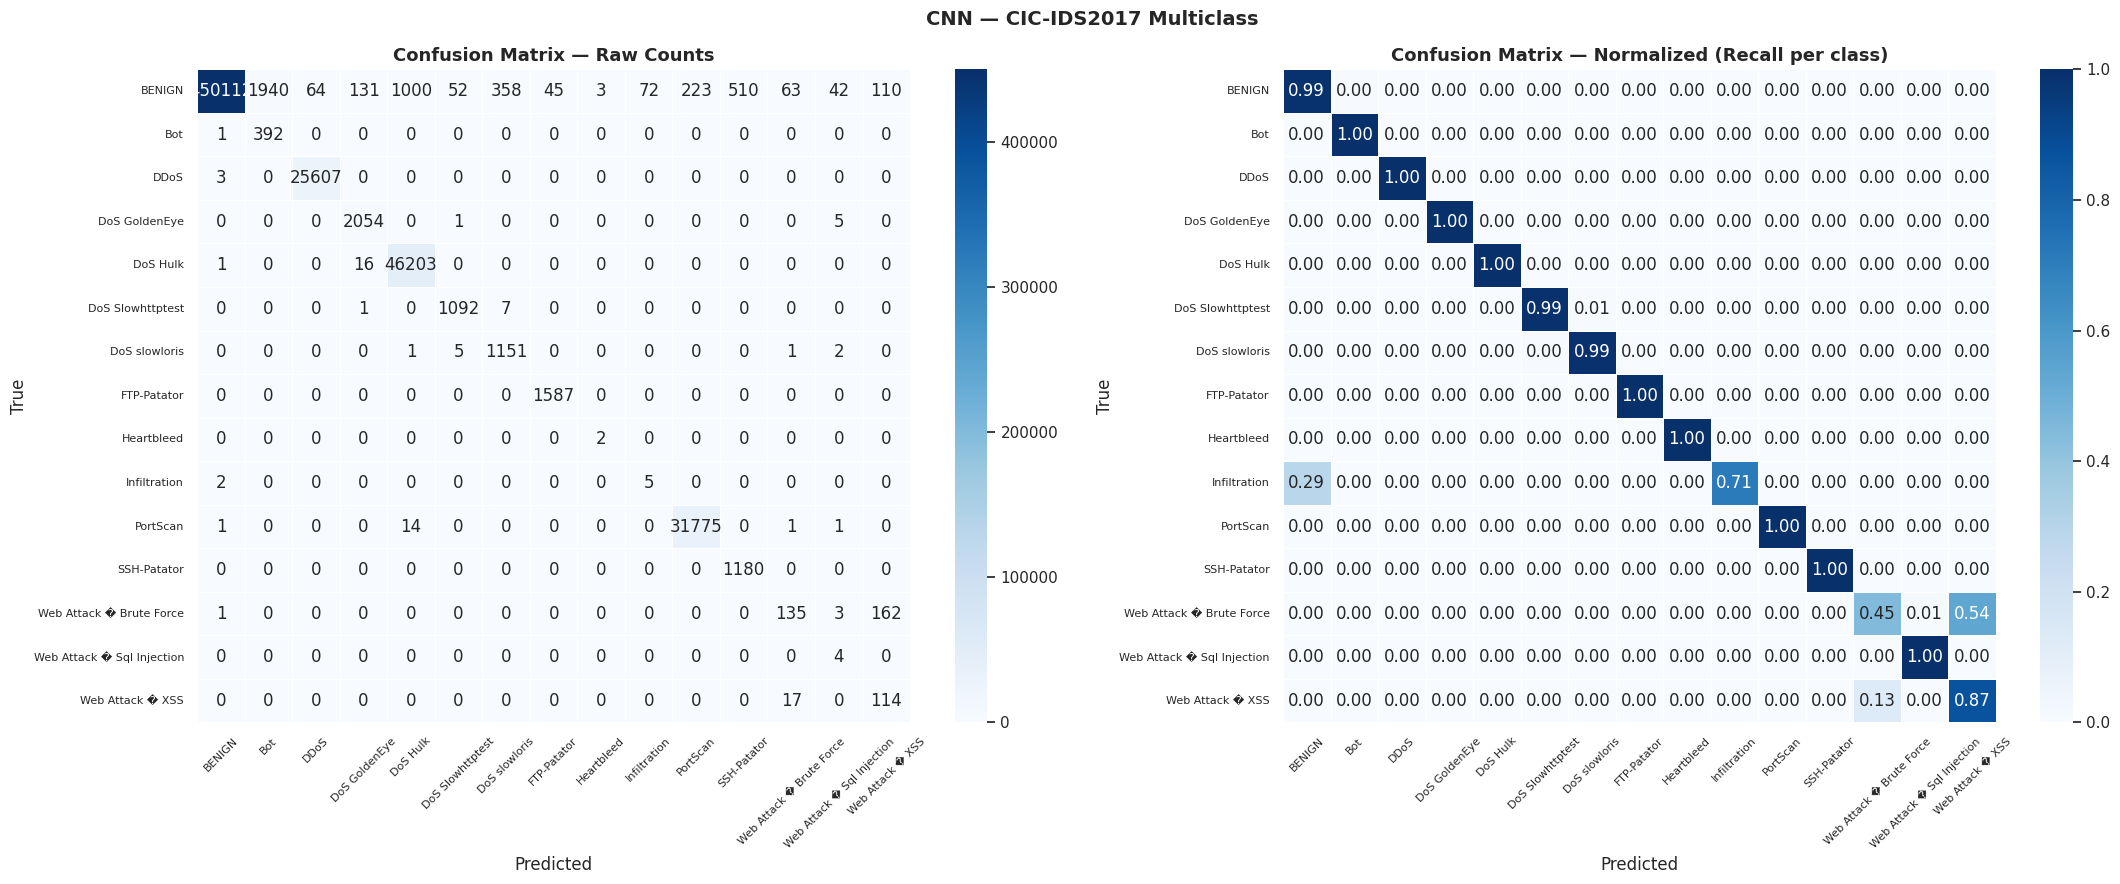

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(22, 9))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Confusion Matrix — Raw Counts', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].tick_params(axis='y', labelsize=8)

cm_norm = cm.astype('float') / (cm.sum(axis=1, keepdims=True) + 1e-8)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Confusion Matrix — Normalized (Recall per class)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
axes[1].tick_params(axis='y', labelsize=8)

plt.suptitle('CNN — CIC-IDS2017 Multiclass', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_cicids2017_multi.png', dpi=150, bbox_inches='tight')
plt.show()

## 16. ROC Curves (Per Class — One-vs-Rest)

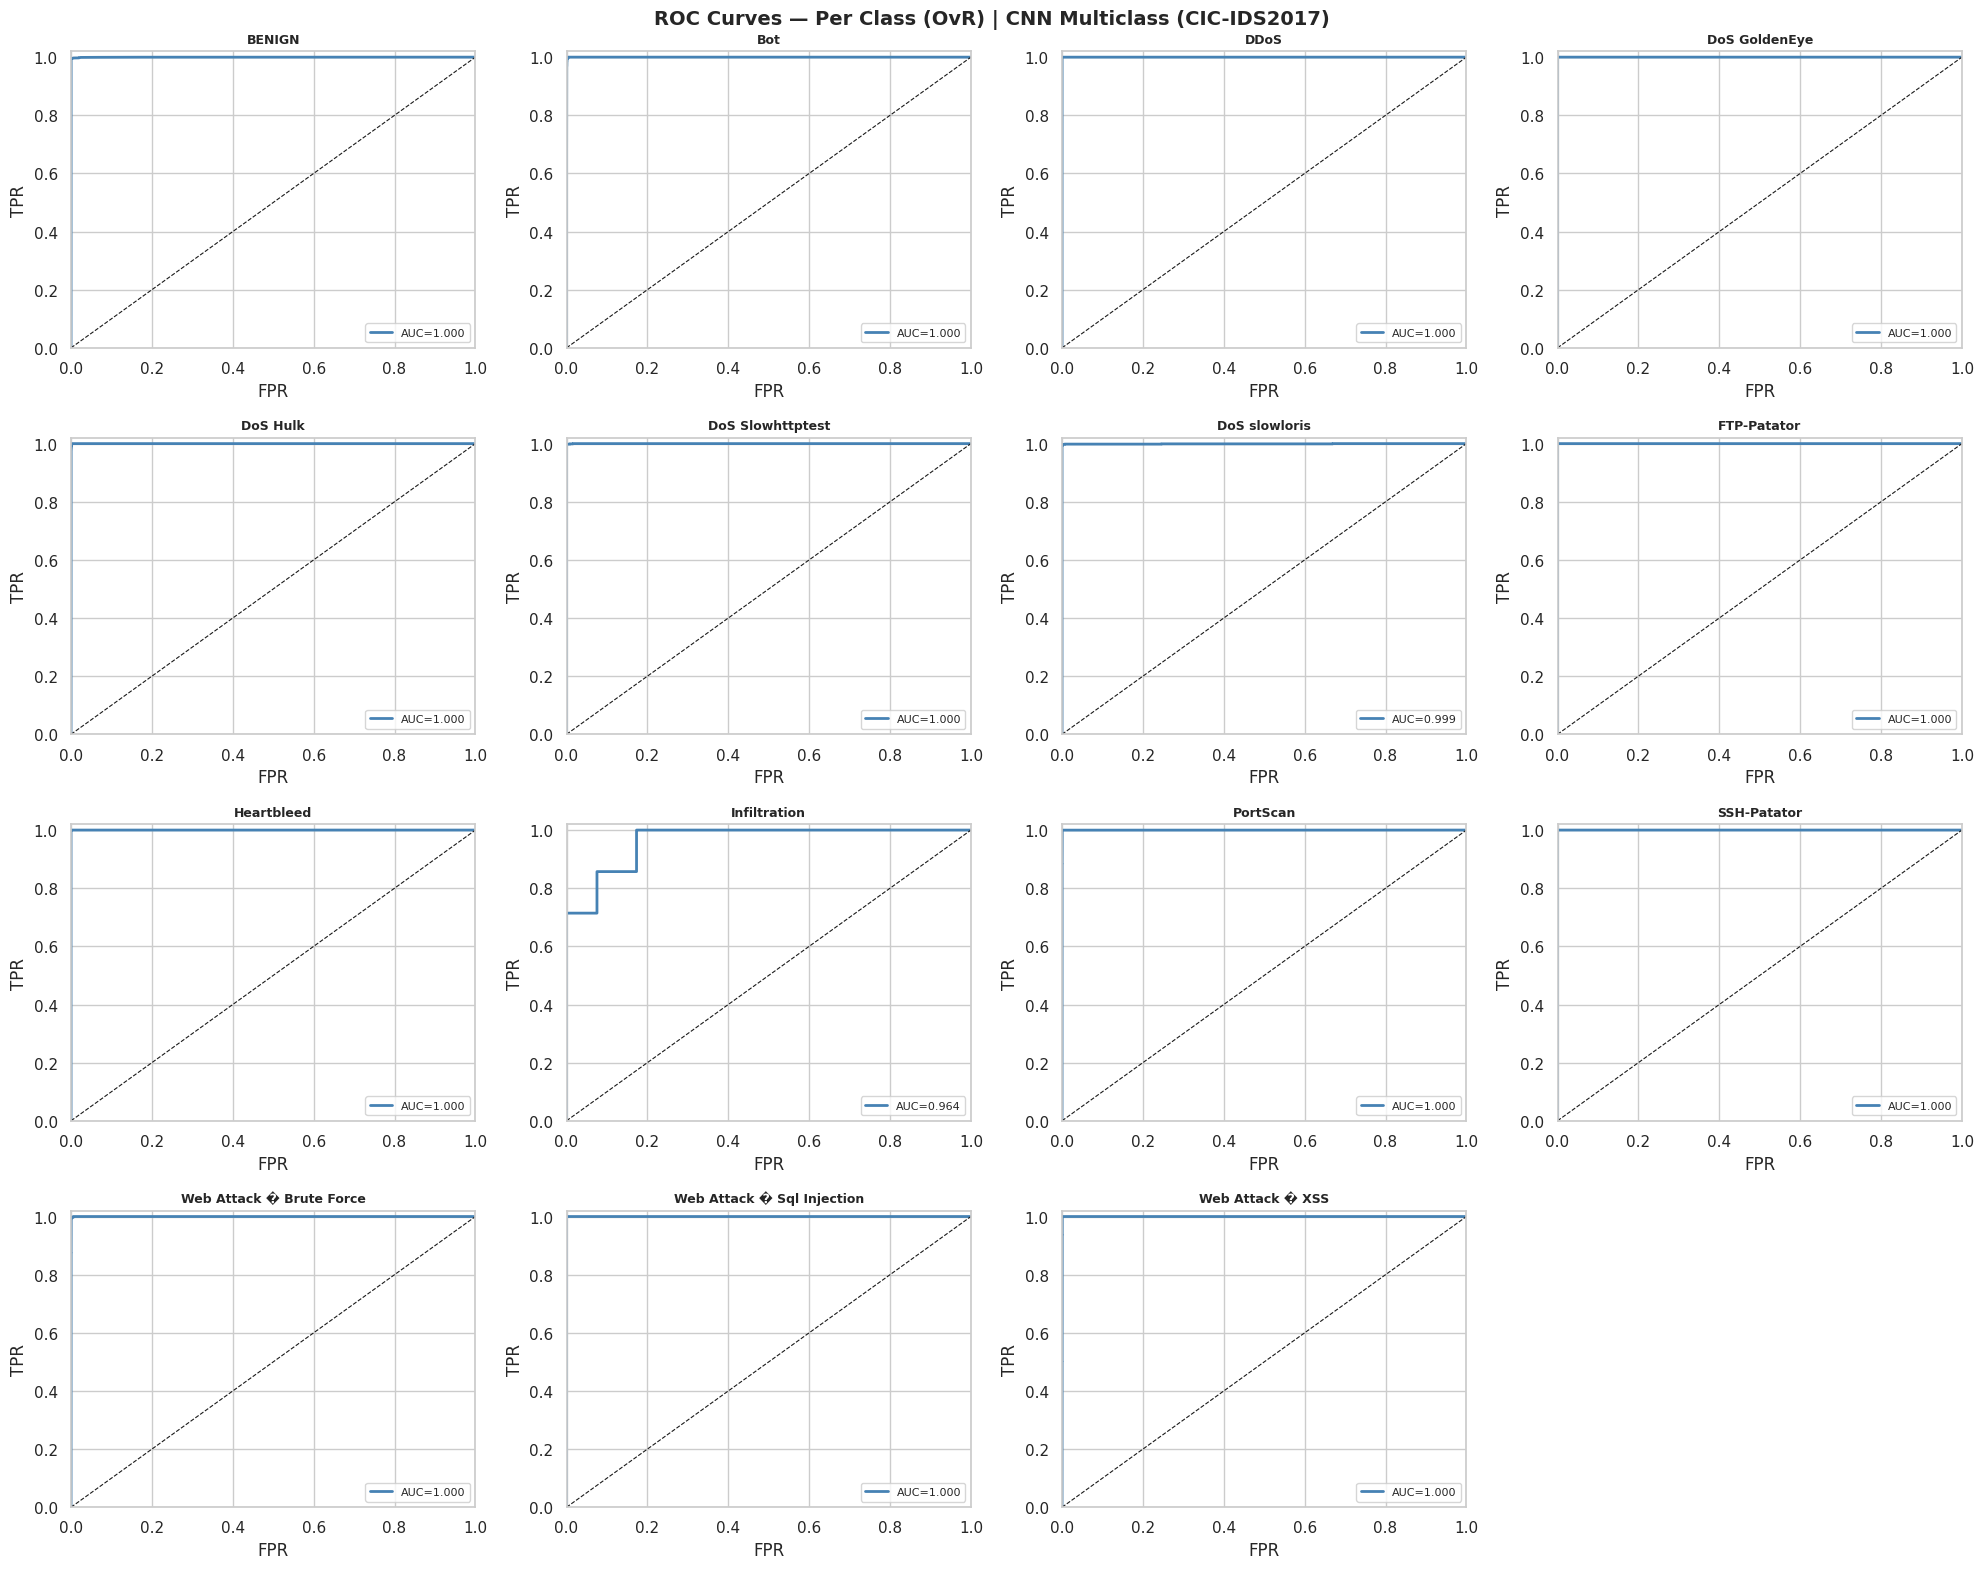

Per-class AUC:
  BENIGN                                   AUC = 0.9998
  Bot                                      AUC = 0.9998
  DDoS                                     AUC = 1.0000
  DoS GoldenEye                            AUC = 1.0000
  DoS Hulk                                 AUC = 1.0000
  DoS Slowhttptest                         AUC = 1.0000
  DoS slowloris                            AUC = 0.9992
  FTP-Patator                              AUC = 1.0000
  Heartbleed                               AUC = 1.0000
  Infiltration                             AUC = 0.9645
  PortScan                                 AUC = 0.9999
  SSH-Patator                              AUC = 1.0000
  Web Attack � Brute Force                 AUC = 0.9998
  Web Attack � Sql Injection               AUC = 1.0000
  Web Attack � XSS                         AUC = 0.9997


In [18]:
y_bin  = label_binarize(y_true, classes=list(range(N_CLASSES)))
n_cols = 4
n_rows = int(np.ceil(N_CLASSES / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4))
axes = axes.flatten()

per_class_auc = []
for c in range(N_CLASSES):
    if y_bin[:, c].sum() == 0:
        per_class_auc.append(float('nan'))
        axes[c].set_visible(False)
        continue
    fpr_c, tpr_c, _ = roc_curve(y_bin[:, c], y_probs[:, c])
    auc_c = auc(fpr_c, tpr_c)
    per_class_auc.append(auc_c)
    axes[c].plot(fpr_c, tpr_c, lw=2, color='steelblue', label=f'AUC={auc_c:.3f}')
    axes[c].plot([0,1],[0,1],'k--', lw=0.8)
    axes[c].set_title(CLASS_NAMES[c], fontsize=9, fontweight='bold')
    axes[c].set_xlabel('FPR'); axes[c].set_ylabel('TPR')
    axes[c].legend(fontsize=8)
    axes[c].set_xlim([0,1]); axes[c].set_ylim([0,1.02])

for ax in axes[N_CLASSES:]:
    ax.set_visible(False)

plt.suptitle('ROC Curves — Per Class (OvR) | CNN Multiclass (CIC-IDS2017)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_curves_cicids2017_multi.png', dpi=150, bbox_inches='tight')
plt.show()

print('Per-class AUC:')
for c, a in enumerate(per_class_auc):
    print(f'  {CLASS_NAMES[c]:<40} AUC = {a:.4f}')

## 17. Precision-Recall Curves (Per Class)

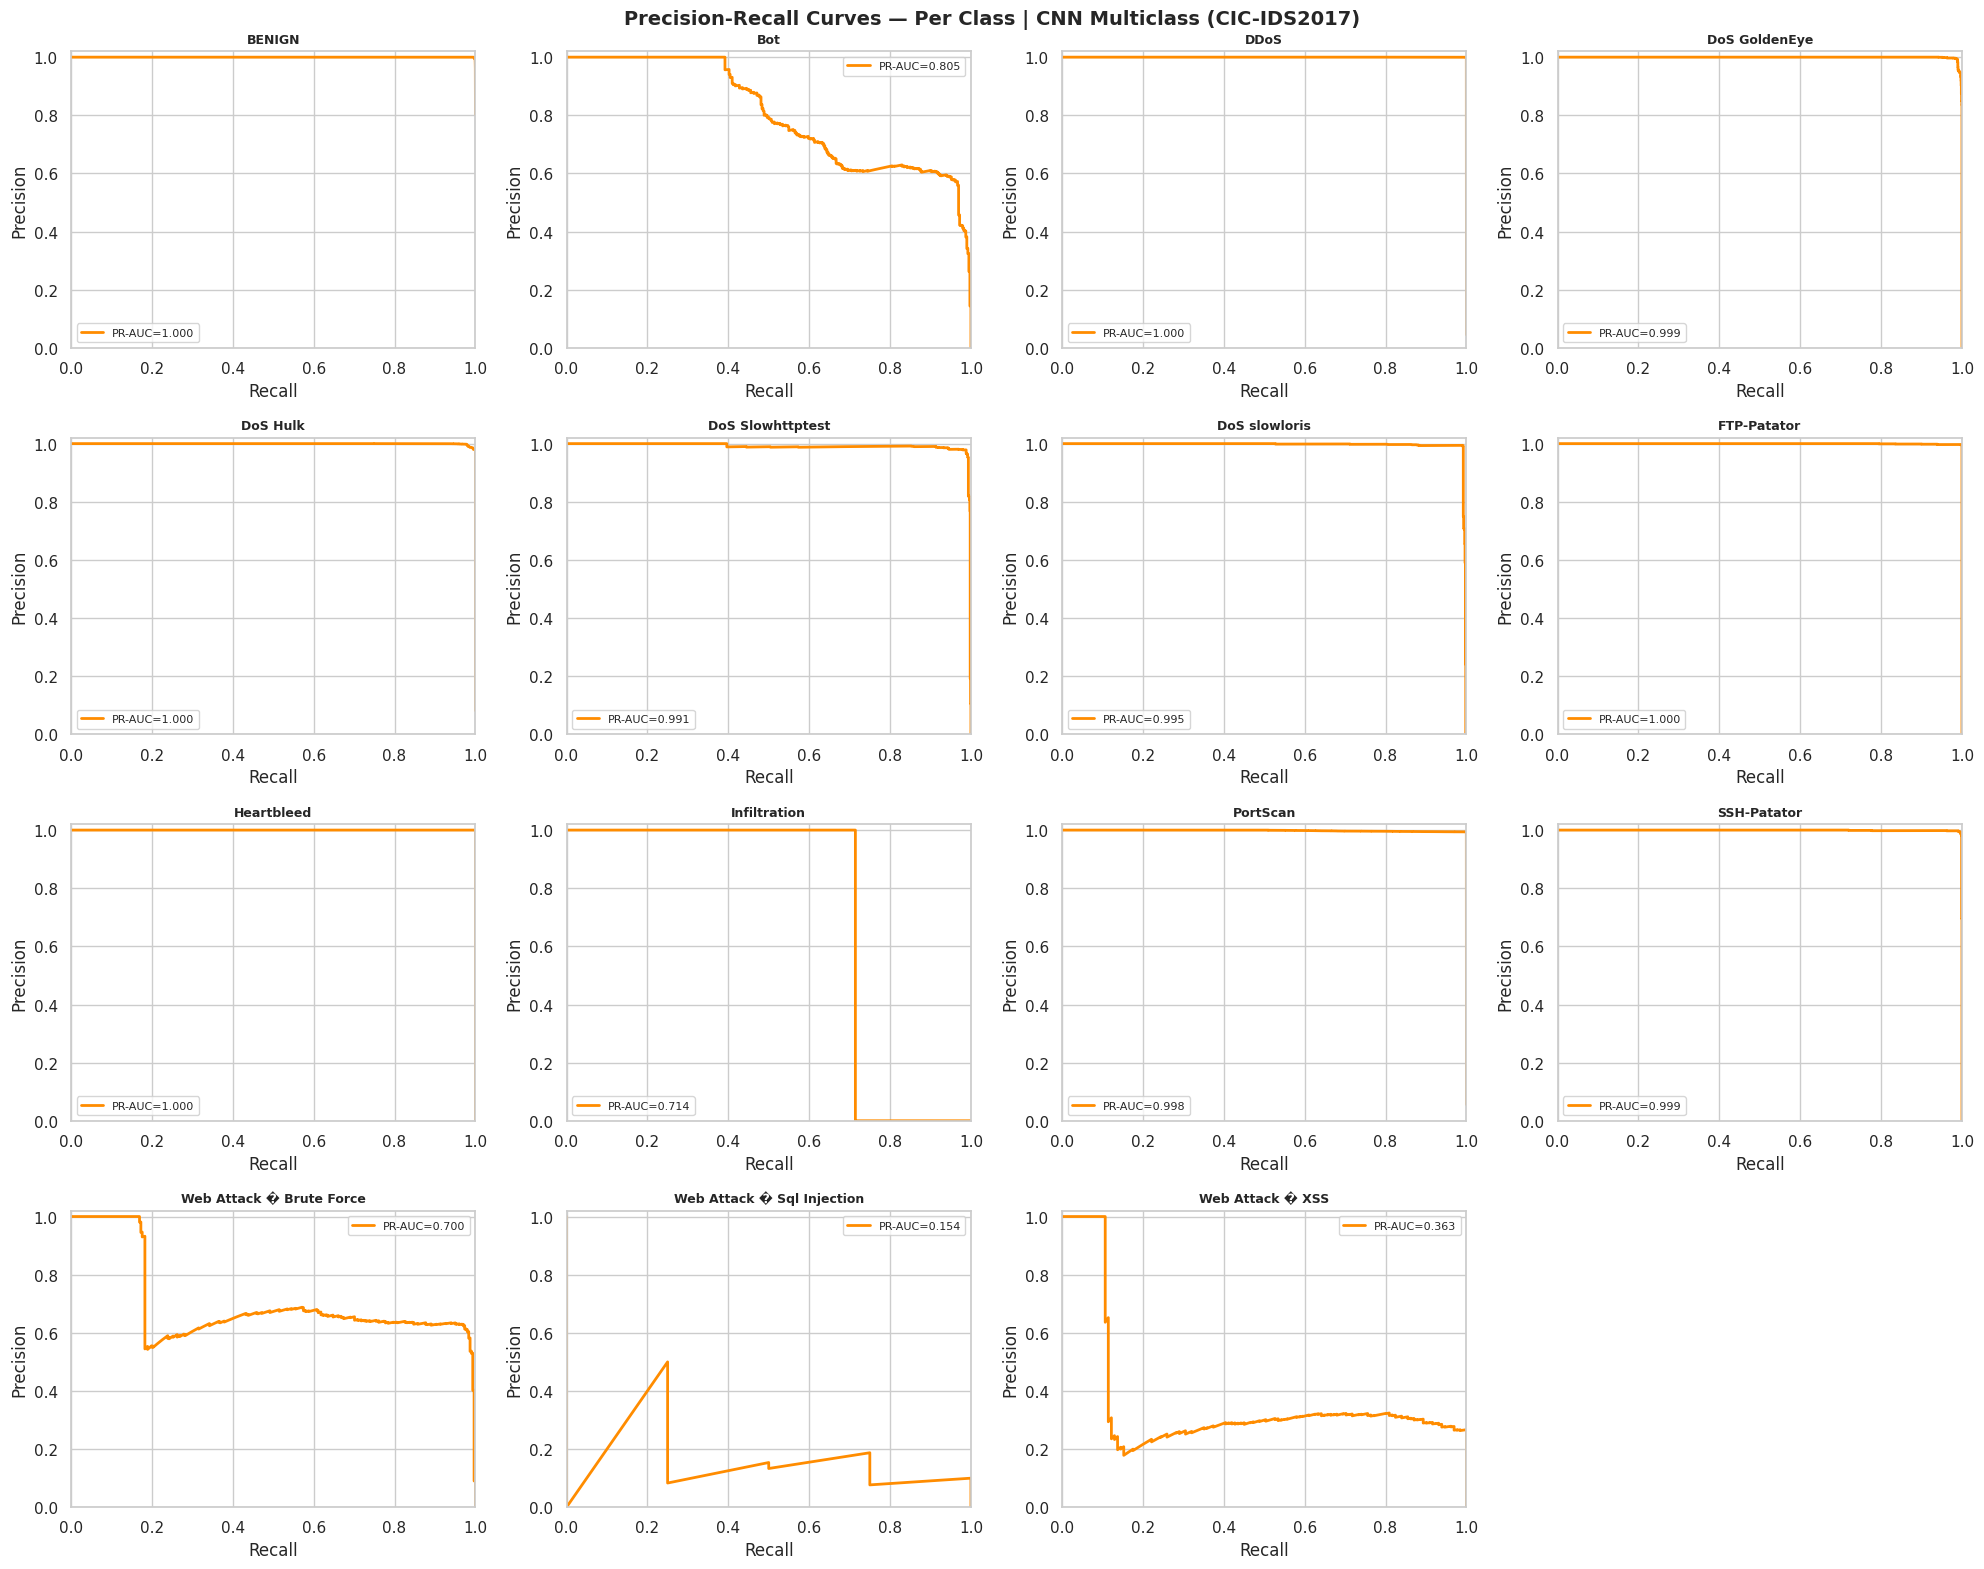

In [19]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4))
axes = axes.flatten()

for c in range(N_CLASSES):
    if y_bin[:, c].sum() == 0:
        axes[c].set_visible(False)
        continue
    prec_c, rec_c, _ = precision_recall_curve(y_bin[:, c], y_probs[:, c])
    pr_auc = auc(rec_c, prec_c)
    axes[c].plot(rec_c, prec_c, lw=2, color='darkorange', label=f'PR-AUC={pr_auc:.3f}')
    axes[c].set_title(CLASS_NAMES[c], fontsize=9, fontweight='bold')
    axes[c].set_xlabel('Recall'); axes[c].set_ylabel('Precision')
    axes[c].legend(fontsize=8)
    axes[c].set_xlim([0,1]); axes[c].set_ylim([0,1.02])

for ax in axes[N_CLASSES:]:
    ax.set_visible(False)

plt.suptitle('Precision-Recall Curves — Per Class | CNN Multiclass (CIC-IDS2017)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('pr_curves_cicids2017_multi.png', dpi=150, bbox_inches='tight')
plt.show()

## 18. Per-Class Metric Bar Charts

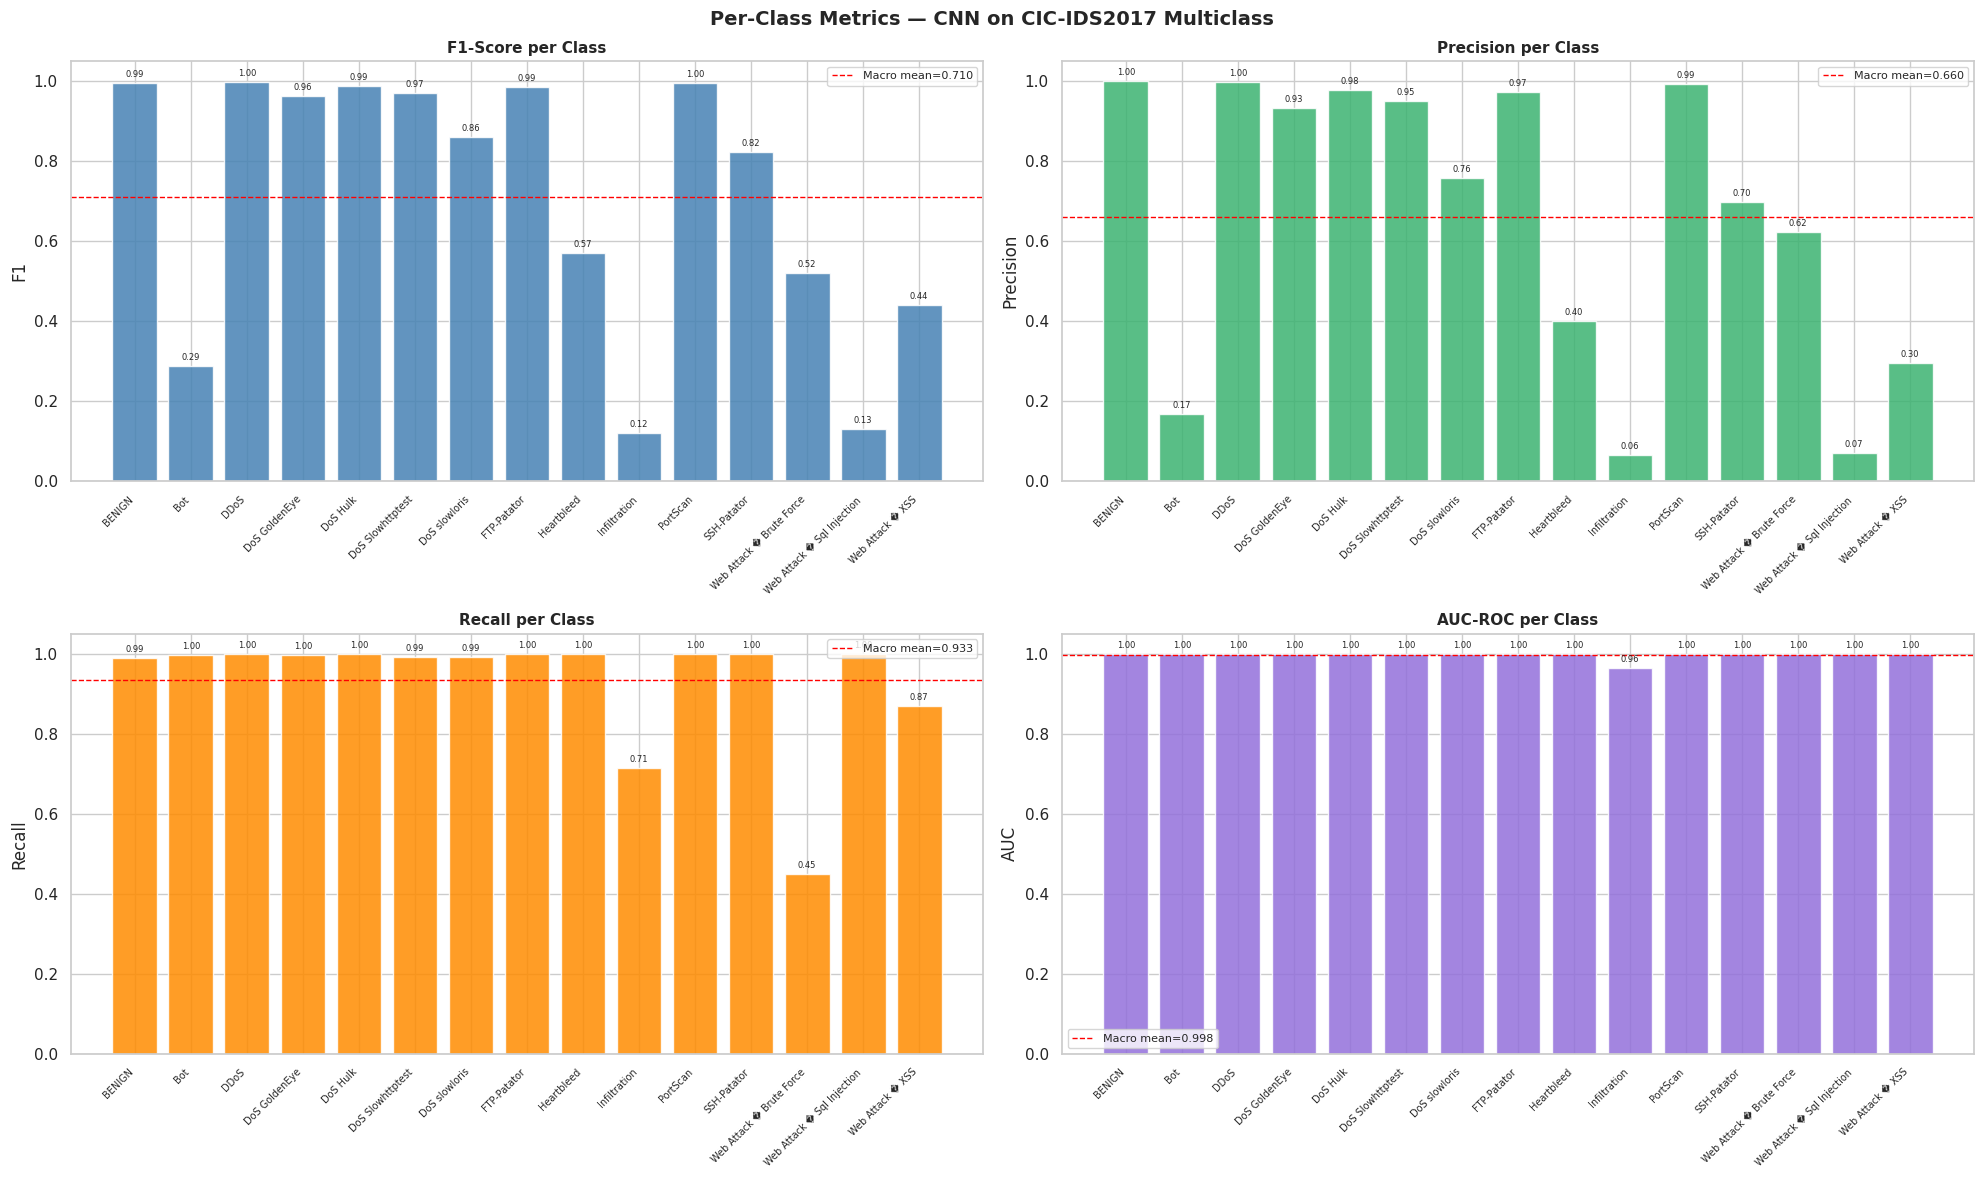

In [20]:
report = classification_report(
    y_true, y_pred, target_names=CLASS_NAMES,
    output_dict=True, zero_division=0
)
f1_per   = [report[c]['f1-score']  for c in CLASS_NAMES]
prec_per = [report[c]['precision'] for c in CLASS_NAMES]
rec_per  = [report[c]['recall']    for c in CLASS_NAMES]

def bar_chart(ax, vals, title, ylabel, color):
    x = range(N_CLASSES)
    bars = ax.bar(x, vals, color=color, edgecolor='white', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=7)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel); ax.set_ylim(0, 1.05)
    ax.axhline(np.nanmean(vals), color='red', linestyle='--', lw=1,
               label=f'Macro mean={np.nanmean(vals):.3f}')
    ax.legend(fontsize=8)
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.01,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=6)

fig, axes = plt.subplots(2, 2, figsize=(20, 12))
bar_chart(axes[0,0], f1_per,        'F1-Score per Class',  'F1',        'steelblue')
bar_chart(axes[0,1], prec_per,      'Precision per Class', 'Precision', 'mediumseagreen')
bar_chart(axes[1,0], rec_per,       'Recall per Class',    'Recall',    'darkorange')
bar_chart(axes[1,1], per_class_auc, 'AUC-ROC per Class',   'AUC',       'mediumpurple')

plt.suptitle('Per-Class Metrics — CNN on CIC-IDS2017 Multiclass',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('per_class_metrics_cicids2017_multi.png', dpi=150, bbox_inches='tight')
plt.show()

## 19. Training Curves (CV Folds)

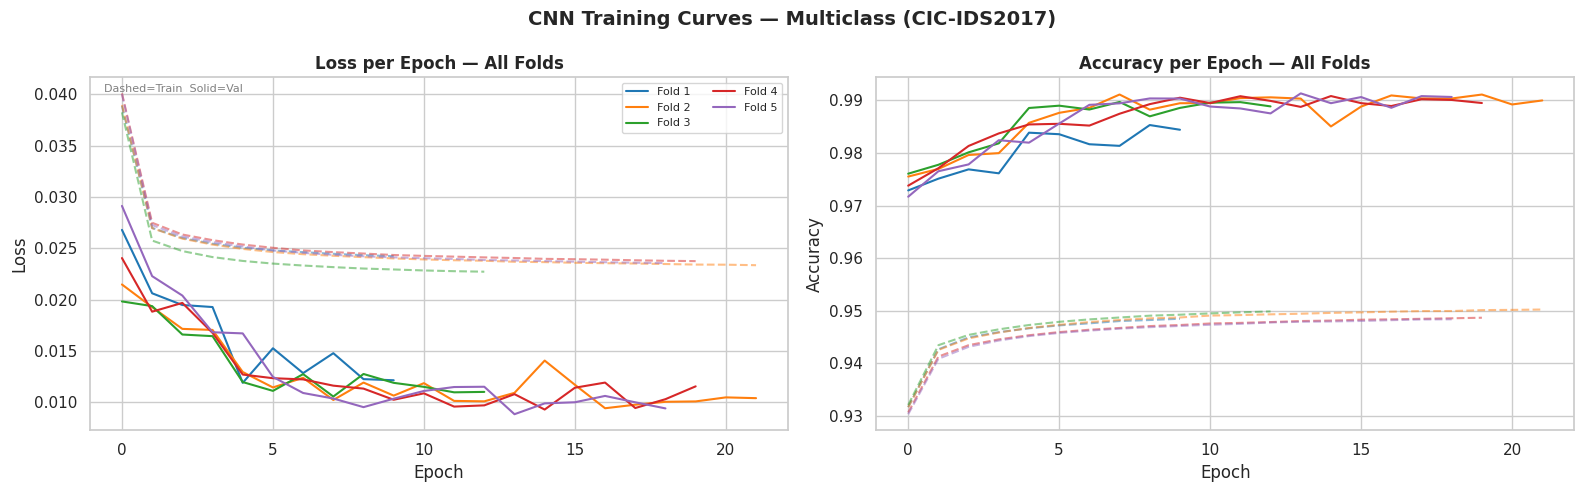

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors = plt.cm.tab10.colors

for i, hist in enumerate(cv_histories):
    c = colors[i]
    axes[0].plot(hist['train_loss'], color=c, alpha=0.5, linestyle='--')
    axes[0].plot(hist['val_loss'],   color=c, alpha=1.0, label=f'Fold {i+1}')
    axes[1].plot(hist['train_acc'],  color=c, alpha=0.5, linestyle='--')
    axes[1].plot(hist['val_acc'],    color=c, alpha=1.0)

axes[0].set_title('Loss per Epoch — All Folds', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=8, ncol=2)
axes[0].text(0.02, 0.98, 'Dashed=Train  Solid=Val',
             transform=axes[0].transAxes, fontsize=8, va='top', color='gray')
axes[1].set_title('Accuracy per Epoch — All Folds', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')

plt.suptitle('CNN Training Curves — Multiclass (CIC-IDS2017)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_training_curves_cicids2017_multi.png', dpi=150, bbox_inches='tight')
plt.show()

## 20. Individual Metric Plots (9 plots)

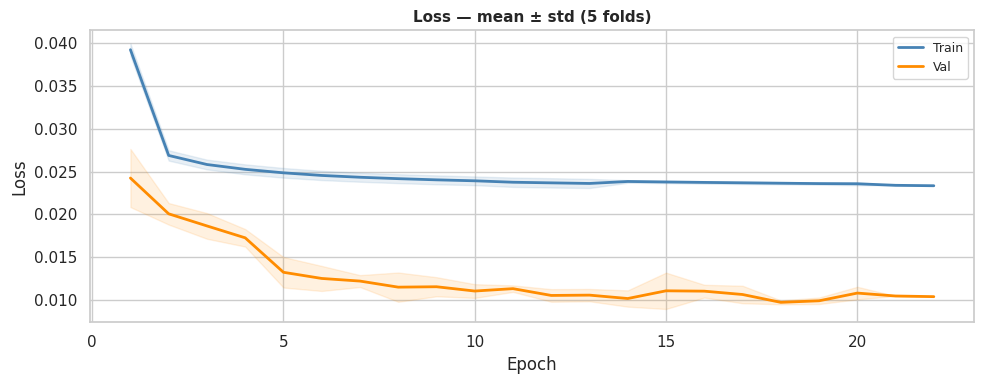

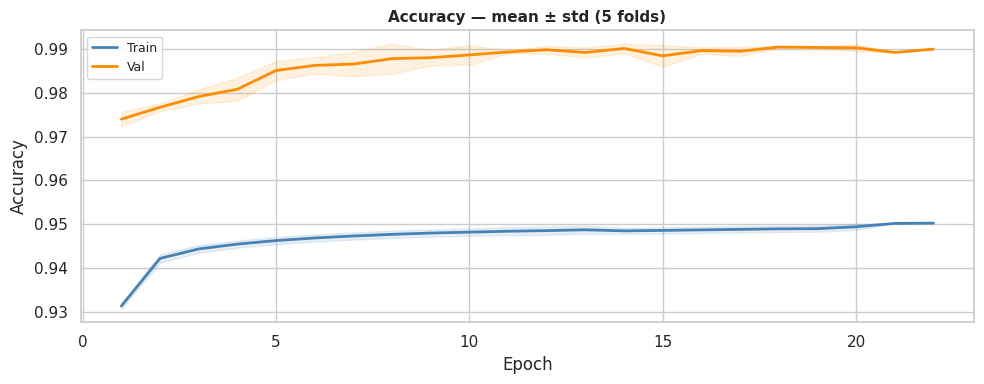

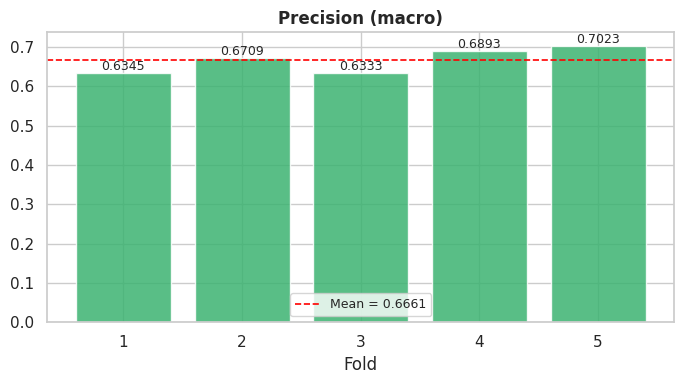

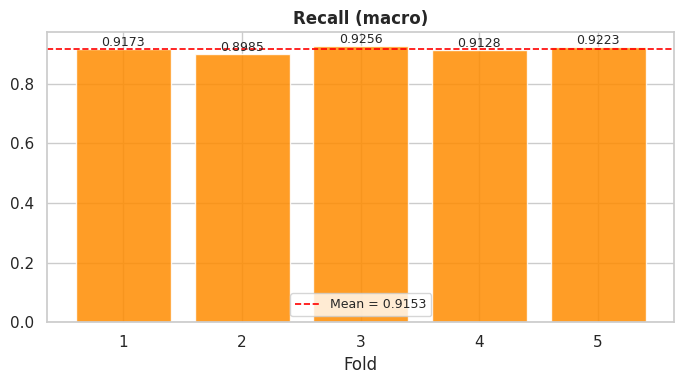

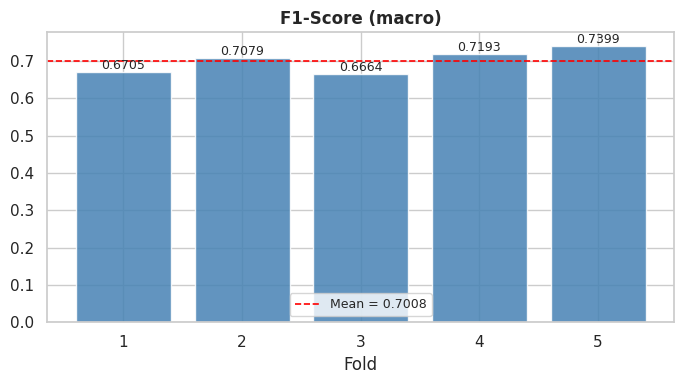

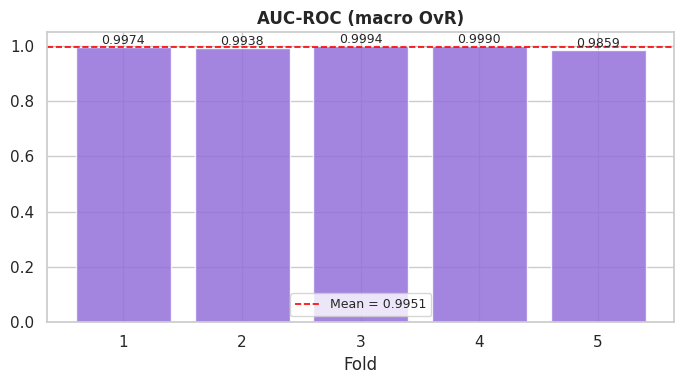

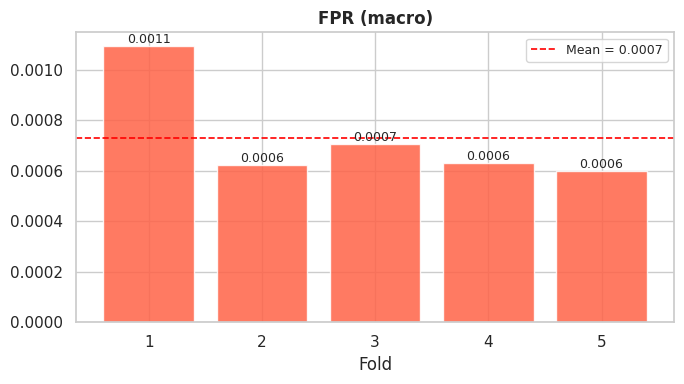

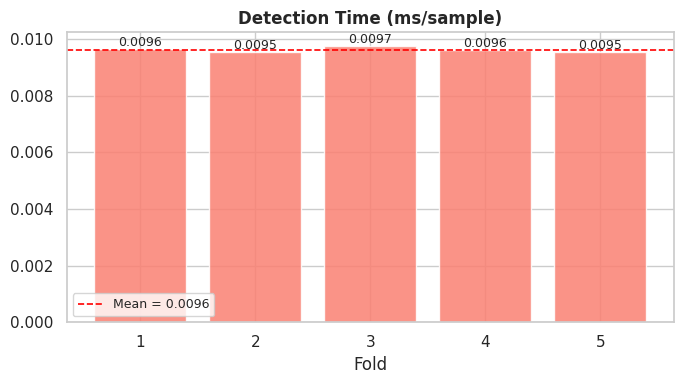

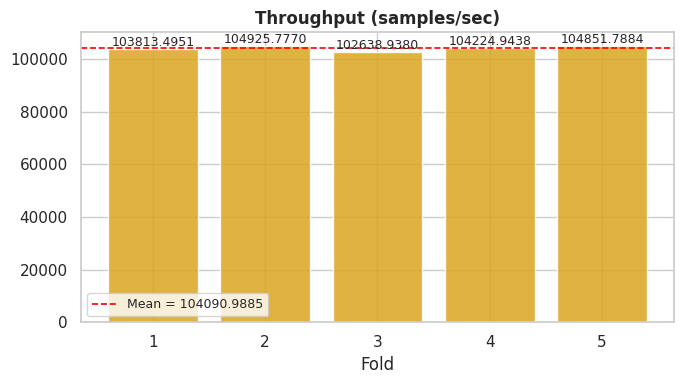

 All 9 individual metric plots saved.


In [22]:
max_ep = max(len(h['train_loss']) for h in cv_histories)

def pad(key):
    arrs = []
    for h in cv_histories:
        a = np.array(h[key])
        if len(a) < max_ep:
            a = np.concatenate([a, np.full(max_ep - len(a), np.nan)])
        arrs.append(a)
    return np.array(arrs)

tr_loss_m = pad('train_loss'); vl_loss_m = pad('val_loss')
tr_acc_m  = pad('train_acc');  vl_acc_m  = pad('val_acc')
ep_x = np.arange(1, max_ep + 1)

def curve_plot(ax, tr, vl, title, ylabel):
    m_tr = np.nanmean(tr, 0); s_tr = np.nanstd(tr, 0)
    m_vl = np.nanmean(vl, 0); s_vl = np.nanstd(vl, 0)
    ax.plot(ep_x, m_tr, 'steelblue',  lw=2, label='Train')
    ax.fill_between(ep_x, m_tr-s_tr, m_tr+s_tr, alpha=0.12, color='steelblue')
    ax.plot(ep_x, m_vl, 'darkorange', lw=2, label='Val')
    ax.fill_between(ep_x, m_vl-s_vl, m_vl+s_vl, alpha=0.12, color='darkorange')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel); ax.legend(fontsize=9)

# 1. Loss
fig, ax = plt.subplots(figsize=(10,4))
curve_plot(ax, tr_loss_m, vl_loss_m, 'Loss — mean ± std (5 folds)', 'Loss')
plt.tight_layout(); plt.savefig('plot_loss.png', dpi=150, bbox_inches='tight'); plt.show()

# 2. Accuracy
fig, ax = plt.subplots(figsize=(10,4))
curve_plot(ax, tr_acc_m, vl_acc_m, 'Accuracy — mean ± std (5 folds)', 'Accuracy')
plt.tight_layout(); plt.savefig('plot_accuracy.png', dpi=150, bbox_inches='tight'); plt.show()

# 3–9. Per-fold scalar metrics
scalar_plots = [
    ('precision',   'Precision (macro)',          'mediumseagreen'),
    ('recall',      'Recall (macro)',             'darkorange'),
    ('f1',          'F1-Score (macro)',           'steelblue'),
    ('roc_auc',     'AUC-ROC (macro OvR)',        'mediumpurple'),
    ('fpr',         'FPR (macro)',                'tomato'),
    ('det_time_ms', 'Detection Time (ms/sample)', 'salmon'),
    ('throughput',  'Throughput (samples/sec)',   'goldenrod'),
]

for col, title, color in scalar_plots:
    vals = cv_df[col].values
    fig, ax = plt.subplots(figsize=(7,4))
    bars = ax.bar(range(1, N_FOLDS+1), vals, color=color, edgecolor='white', alpha=0.85)
    ax.axhline(vals.mean(), color='red', linestyle='--', lw=1.2,
               label=f'Mean = {vals.mean():.4f}')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Fold'); ax.set_xticks(range(1, N_FOLDS+1))
    ax.legend(fontsize=9)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{v:.4f}', ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.savefig(f'plot_{col}.png', dpi=150, bbox_inches='tight')
    plt.show()

print(' All 9 individual metric plots saved.')

## 21. Per-Fold Summary Bar Chart

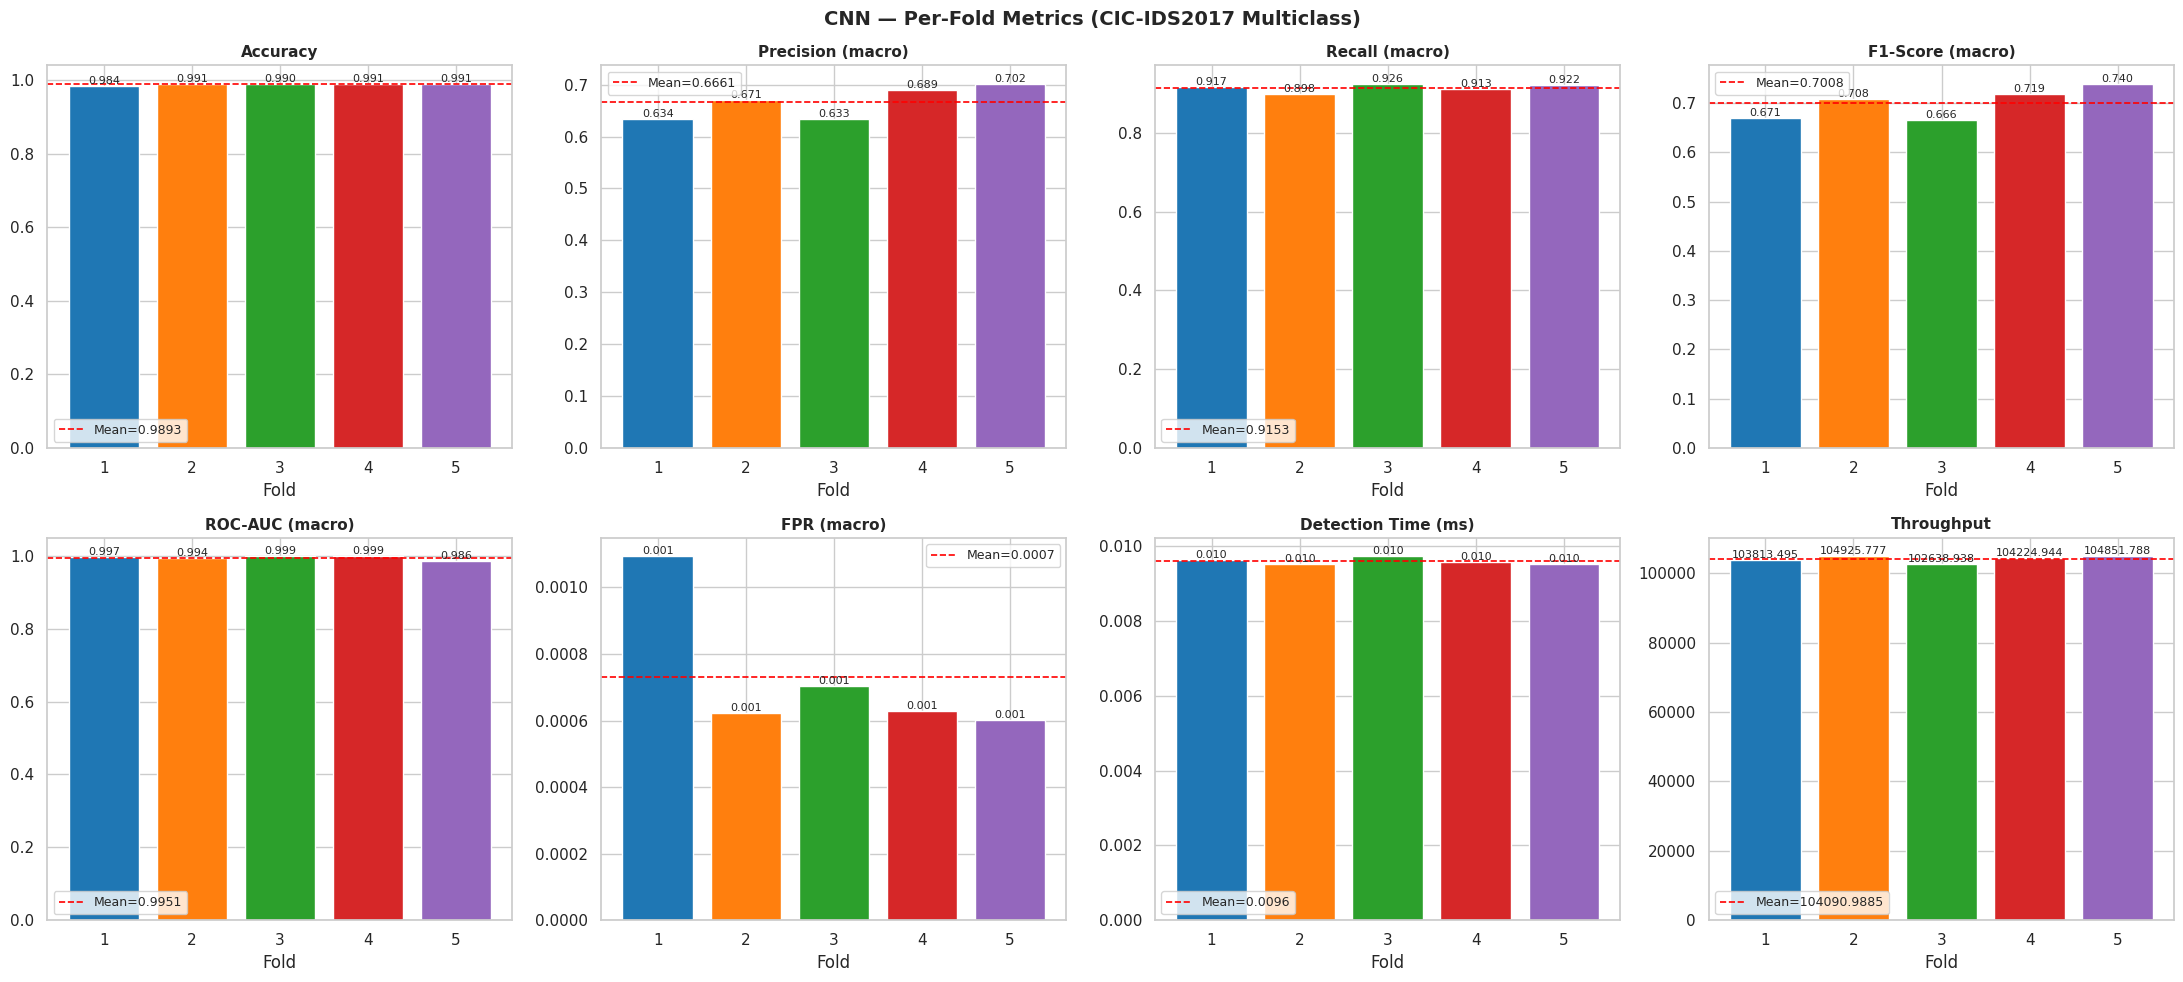

In [23]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes  = axes.flatten()
folds = cv_df.index.tolist()

all_metrics = [
    ('acc',         'Accuracy'),
    ('precision',   'Precision (macro)'),
    ('recall',      'Recall (macro)'),
    ('f1',          'F1-Score (macro)'),
    ('roc_auc',     'ROC-AUC (macro)'),
    ('fpr',         'FPR (macro)'),
    ('det_time_ms', 'Detection Time (ms)'),
    ('throughput',  'Throughput'),
]

for ax, (col, title) in zip(axes, all_metrics):
    vals = cv_df[col].values
    bars = ax.bar(folds, vals, color=plt.cm.tab10.colors[:N_FOLDS], edgecolor='white')
    ax.axhline(vals.mean(), color='red', linestyle='--', lw=1.2,
               label=f'Mean={vals.mean():.4f}')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Fold'); ax.set_xticks(folds)
    ax.legend(fontsize=9)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('CNN — Per-Fold Metrics (CIC-IDS2017 Multiclass)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('per_fold_metrics_cicids2017_multi.png', dpi=150, bbox_inches='tight')
plt.show()

## 22. Save Best Model

In [24]:
save_path = 'cnn_cicids2017_multiclass_best.pt'
torch.save({
    'model_state_dict': best_model.state_dict(),
    'n_features'      : N_FEATURES,
    'n_classes'       : N_CLASSES,
    'class_names'     : CLASS_NAMES,
    'feature_cols'    : FEATURE_COLS,
    'label_encoder'   : le,
    'cnn_blocks'      : CNN_BLOCKS,
    'cnn_dropout'     : CNN_DROPOUT,
    'pool_size'       : POOL_SIZE,
    'fc_layers'       : FC_LAYERS,
    'fc_dropout'      : FC_DROPOUT,
    'best_fold'       : best_fold_idx + 1,
    'cv_results'      : cv_df.to_dict(),
    'test_metrics'    : {
        'acc': acc, 'precision': prec, 'recall': rec, 'f1': f1,
        'fpr': fpr_macro, 'roc_auc': roc_auc,
        'det_time_ms': det_time_ms, 'throughput': throughput
    }
}, save_path)
print(f' Model saved → {save_path}')
print(f'  Dataset      : CIC-IDS2017 | Task: Multiclass')
print(f'  Architecture : CNN1D  blocks={CNN_BLOCKS}')
print(f'  Features     : {N_FEATURES}')
print(f'  Classes      : {N_CLASSES}  →  {CLASS_NAMES}')
print(f'  Best fold    : {best_fold_idx + 1}')



 Model saved → cnn_cicids2017_multiclass_best.pt
  Dataset      : CIC-IDS2017 | Task: Multiclass
  Architecture : CNN1D  blocks=[(64, 3), (128, 3), (256, 3)]
  Features     : 78
  Classes      : 15  →  ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack � Brute Force', 'Web Attack � Sql Injection', 'Web Attack � XSS']
  Best fold    : 5
